## MMAI Homework1 Data Preparation


[Original code](https://colab.research.google.com/drive/19G0kokdpszoaWgBJNUwednuAsN2PwfS1?usp=sharing)

[Homework1 sample](https://colab.research.google.com/drive/19bWh-waJu8D3jsQRsbBhz2EgblgdU8VJ)

*I enrolled in the course late, which caused my HW1 submission to be delayed. I have already informed the TA and received permission. I apologize for any inconvenience caused.*

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:


1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.
2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.
3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?
4. What difficulties did you encounter in obtaining the data?
5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?


Answers to the above questions:

**1. Project Goal**

I am interested in building a multimodal model that aligns music and human motion — two relatively underexplored modalities — with applications in artistic creation. Concretely, the model could support tasks such as choreography generation from music, motion-conditioned music generation, or automated evaluation of dance-music correspondence. This is a compelling testbed for cross-modal alignment because rhythm, melody, and dynamics in music interact with timing, style, and expressiveness in motion in non-trivial ways.

**2. Datasets**

| Dataset | Paper | Link |
|---|---|---|
| AIST++ | [Paper](https://arxiv.org/pdf/2101.08779) | [Link](https://google.github.io/aistplusplus_dataset/download.html) |
| TikTok Dance-Music | [Paper](https://arxiv.org/pdf/2204.00604) | [Link](https://github.com/L-YeZhu/D2M-GAN) |
| SoulDance | [Paper](https://arxiv.org/abs/2507.14915) | [Link](https://drive.google.com/drive/folders/1fbZcHUbc6kT_lpKfzh0PvOAlxM2s7mcN) *(provided by authors personally, not public)* |

- **Why relevant:** All three datasets contain paired music–dance recordings, suitable for audio–motion alignment.
- **Drawbacks:** AIST++ uses only instrumental music; SoulDance removed vocals due to copyright — both limit the text modality. TikTok Dance-Music introduces noise from social media sourcing.

**3. Modalities Used**

- **Music (audio)** 
- **Motion (video/skeleton)** 
- **Music lyrics (text)** 


**4. Difficulties in Obtaining the Data**

- **Scale:** Video data is large, making storage and preprocessing non-trivial.
- **Missing text modality:** AIST++ (instrumental only) and SoulDance (vocals removed) both lack lyrics, so the text modality is sparse or unavailable across datasets.

**5. Six Core Challenges of Multimodal Learning**

- **Representation:** Each modality needs its own encoder (e.g., spectrogram model for audio, pose estimator for motion, language model for lyrics), with the challenge of making representations semantically comparable across very different signal types.
- **Alignment:** Music, motion, and lyrics must be temporally aligned, with the added complexity that lyrics align at word/phrase granularity while motion aligns at frame level.
- **Reasoning:** The key challenge is capturing higher-order interactions — e.g., a model must reason about deliberate contrast between high-energy music and restrained movement, rather than naively correlating modalities.
- **Generation:** Natural downstream tasks include music-to-dance and dance-to-music generation, requiring coherent sequence synthesis conditioned on another modality.
- **Transference:** Evaluate robustness under missing-modality conditions (e.g., audio-only, no lyrics) as an ablation study.
- **Quantification:** Compare unimodal vs. multimodal performance, and analyz

Summaries of the paper:

1. This paper is a survey/tutorial on multimodal machine learning, the study of systems that integrate multiple modalities of data (e.g., text, images, audio, video, sensor signals) to perform tasks like understanding, reasoning, and generation.
2. The authors define three core principles that underlie multimodal learning: Heterogeneity, Connections, and Interactions.
3. Furthermore, this paper proposes a taxonomy of six core technical challenges in multimodal ML: Representation, Alignment, Reasoning, Generation, Transference, and Quantification.
4. Lastly, this paper highlights some open challenges that remain underexplored.





(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  

- **Scale**: Video data is large, making storage and preprocessing non-trivial. For now, I only process a small sample; efficiently extracting audio from the full dataset at scale remains an open engineering challenge.
- **Missing text modality**: AIST++ uses only instrumental music, and SoulDance removed vocals due to copyright restrictions, so lyrics are largely unavailable across both datasets. This is a known limitation and will be revisited in future work.

In [ ]:
!pip install opencv-python
!pip install datasets

In [10]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

import glob
import numpy as np
from tqdm import tqdm

import os
import requests
import matplotlib.animation as animation
from IPython.display import HTML
import pickle
import librosa.display

from datasets import load_dataset
from huggingface_hub import hf_hub_download, list_repo_files
import pickle
import warnings
warnings.filterwarnings('ignore')


(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

## Dataset Description
Music & Motion

Music-aligned dance enhances emotional expressiveness, yet no standardized metrics jointly evaluate rhythm, beat, and semantic consistency between music and motion. Prior work addresses generation (e.g., Bailando, FACT) or motion quality in isolation. This project builds a music–motion alignment benchmark as a foundation for downstream tasks such as K-pop dance generation.

Consider two datasets:

- [SoulDance](https://xjli360.github.io/SoulDance): I have obtained [the processed dataset](https://drive.google.com/drive/folders/1fbZcHUbc6kT_lpKfzh0PvOAlxM2s7mcN) from the author, but the vocal is removed due to a legal issue.

- [AIST++](https://google.github.io/aistplusplus_dataset)

The dataset includes two modalities: **music** and **motion**, and I visualize each modality separately.

Since I did not use embeddings, I combined the data distribution and input distribution sections into a single part.


## 1. Motion Modality

In [11]:
# Download a specific pkl file
filename = "keypoints2d/gBR_sBM_cAll_d04_mBR0_ch01.pkl"
path = hf_hub_download(
    repo_id="Emmaruyi/AIST",
    filename=filename,  
    repo_type="dataset"
)

### 1.1 Motion Data Distribution/Input Distribution

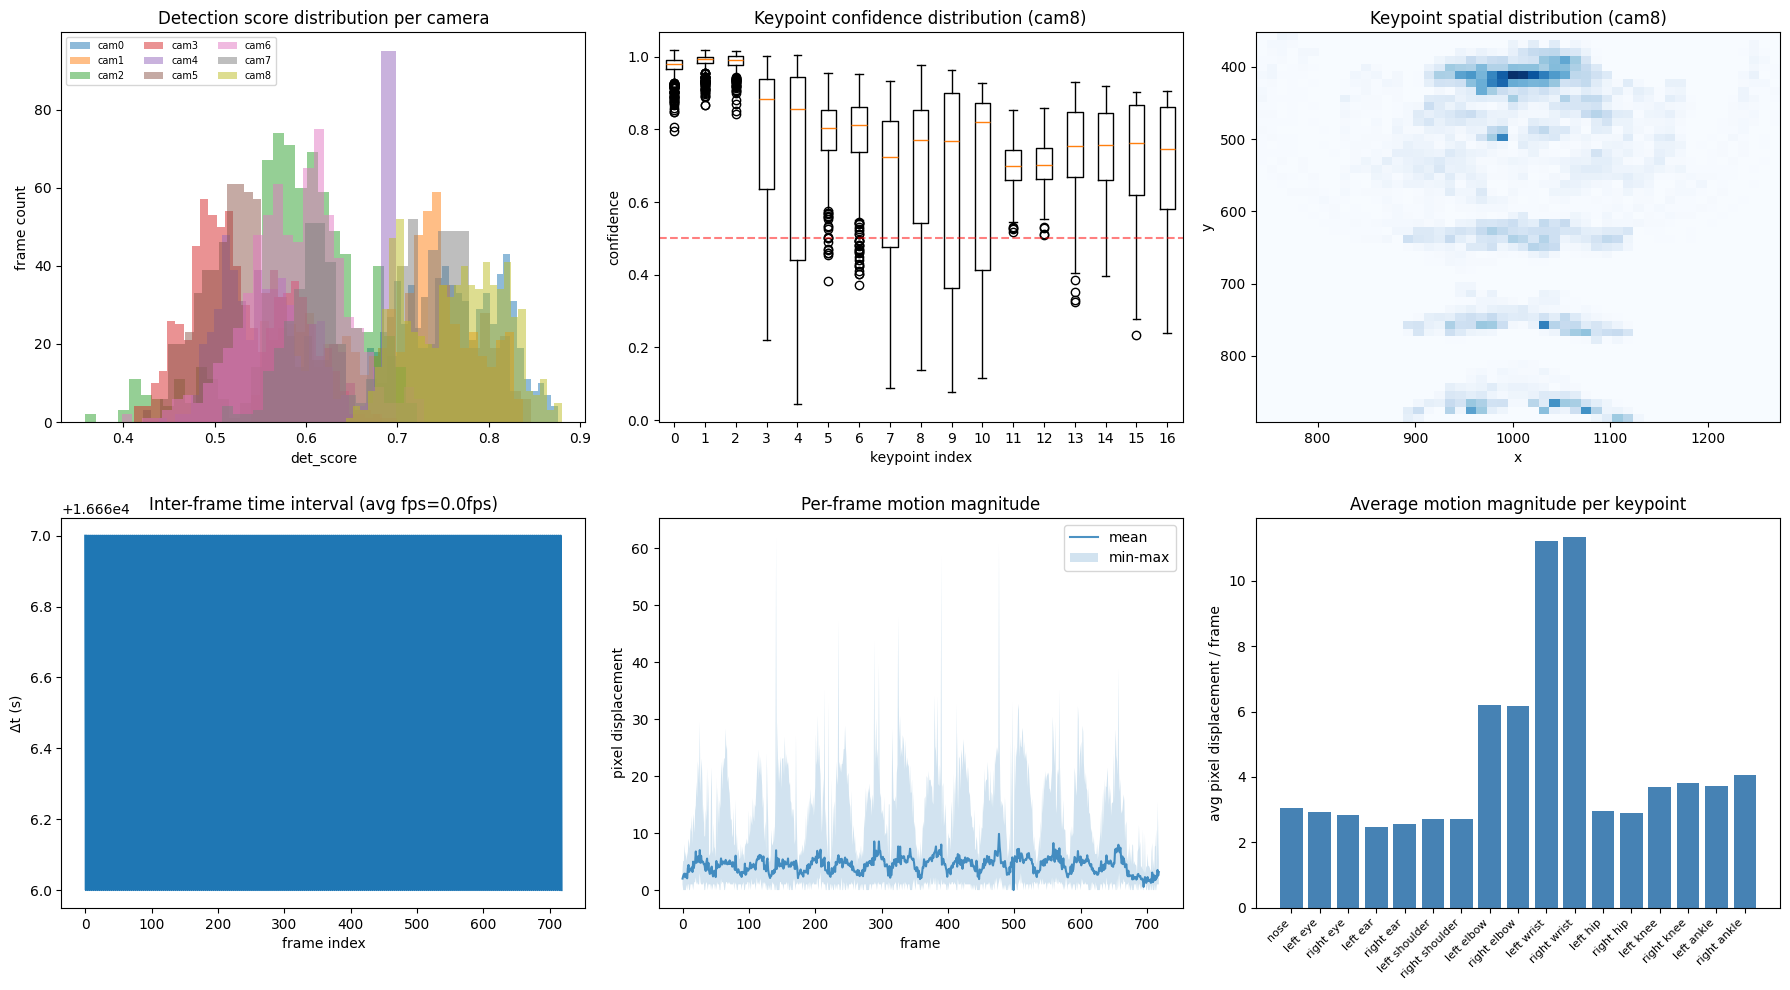

In [20]:
# Load one file as an example
with open(path, "rb") as f:
    data = pickle.load(f)

kp = data['keypoints2d']      # (9, 720, 17, 3)
scores = data['det_scores']   # (9, 720)
ts = data['timestamps']       # (720,)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- (A) Detection confidence distribution across cameras ---
ax = axes[0, 0]
for cam_i in range(kp.shape[0]):
    ax.hist(scores[cam_i], bins=30, alpha=0.5, label=f"cam{cam_i}")
ax.set_title("Detection score distribution per camera")
ax.set_xlabel("det_score"); ax.set_ylabel("frame count")
ax.legend(fontsize=7, ncol=3)

# --- (B) Confidence distribution per keypoint (best camera) ---
best_cam = scores.mean(axis=1).argmax()
conf = kp[best_cam, :, :, 2]  # (720, 17)
ax = axes[0, 1]
ax.boxplot(conf, labels=[str(i) for i in range(17)])
ax.set_title(f"Keypoint confidence distribution (cam{best_cam})")
ax.set_xlabel("keypoint index"); ax.set_ylabel("confidence")
ax.axhline(0.5, color='r', linestyle='--', alpha=0.5)

# --- (C) Keypoint x/y coordinate spatial distribution ---
ax = axes[0, 2]
x_coords = kp[best_cam, :, :, 0].flatten()
y_coords = kp[best_cam, :, :, 1].flatten()
ax.hist2d(x_coords, y_coords, bins=50, cmap='Blues')
ax.set_title(f"Keypoint spatial distribution (cam{best_cam})")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.invert_yaxis()  # image coordinates: y-axis points downward

# --- (D) Timestamp intervals (frame rate stability) ---
ax = axes[1, 0]
dt = np.diff(ts)
ax.plot(dt)
ax.set_title(f"Inter-frame time interval (avg fps={1/dt.mean():.1f}fps)")
ax.set_xlabel("frame index"); ax.set_ylabel("\u0394t (s)")

# --- (E) Body motion magnitude (keypoint displacement between consecutive frames) ---
ax = axes[1, 1]
xy = kp[best_cam, :, :, :2]  # (720, 17, 2)
motion = np.linalg.norm(np.diff(xy, axis=0), axis=-1)  # (719, 17)
ax.plot(motion.mean(axis=1), label="mean", alpha=0.8)
ax.fill_between(range(len(motion)),
                motion.min(axis=1),
                motion.max(axis=1), alpha=0.2, label="min-max")
ax.set_title("Per-frame motion magnitude")
ax.set_xlabel("frame"); ax.set_ylabel("pixel displacement")
ax.legend()

# --- (F) Average motion per keypoint (which body part moves the most) ---
COCO_NAMES = ['nose', 'left eye', 'right eye', 'left ear', 'right ear',
              'left shoulder', 'right shoulder', 'left elbow', 'right elbow', 'left wrist', 'right wrist',
              'left hip', 'right hip', 'left knee', 'right knee', 'left ankle', 'right ankle']
ax = axes[1, 2]
mean_motion = motion.mean(axis=0)  # (17,)
bars = ax.bar(COCO_NAMES, mean_motion, color='steelblue')
ax.set_title("Average motion magnitude per keypoint")
ax.set_xticklabels(COCO_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("avg pixel displacement / frame")

plt.tight_layout()
plt.savefig("distribution.png", dpi=150)
plt.show()


Skipping NaN/Inf: gBR_sMM_cAll_d05_mBR2_ch05.pkl
Skipping NaN/Inf: gHO_sFM_cAll_d20_mHO1_ch09.pkl
Skipping NaN/Inf: gJS_sFM_cAll_d01_mJS1_ch07.pkl
Skipping NaN/Inf: gJS_sMM_cAll_d02_mJS0_ch04.pkl
Skipping NaN/Inf: gJS_sMM_cAll_d01_mJS0_ch01.pkl
Skipping NaN/Inf: gHO_sFM_cAll_d20_mHO5_ch13.pkl
Skipping NaN/Inf: gKR_sFM_cAll_d28_mKR5_ch06.pkl
Skipping NaN/Inf: gJS_sFM_cAll_d01_mJS0_ch01.pkl
Skipping NaN/Inf: gJS_sMM_cAll_d02_mJS1_ch02.pkl
Skipping NaN/Inf: gKR_sFM_cAll_d30_mKR0_ch15.pkl
Skipping NaN/Inf: gBR_sFM_cAll_d05_mBR4_ch11.pkl
Skipping NaN/Inf: gHO_sFM_cAll_d19_mHO3_ch04.pkl
Skipping NaN/Inf: gBR_sBM_cAll_d05_mBR1_ch09.pkl
Skipping NaN/Inf: gMH_sFM_cAll_d22_mMH1_ch07.pkl
Skipping NaN/Inf: gBR_sFM_cAll_d05_mBR5_ch14.pkl
Skipping NaN/Inf: gJB_sFM_cAll_d09_mJB1_ch16.pkl
Skipping NaN/Inf: gHO_sMM_cAll_d20_mHO3_ch05.pkl
Skipping NaN/Inf: gJS_sFM_cAll_d02_mJS3_ch04.pkl
Skipping NaN/Inf: gJB_sFM_cAll_d07_mJB3_ch07.pkl
Skipping NaN/Inf: gBR_sFM_cAll_d04_mBR4_ch07.pkl
Skipping NaN/Inf: gJ

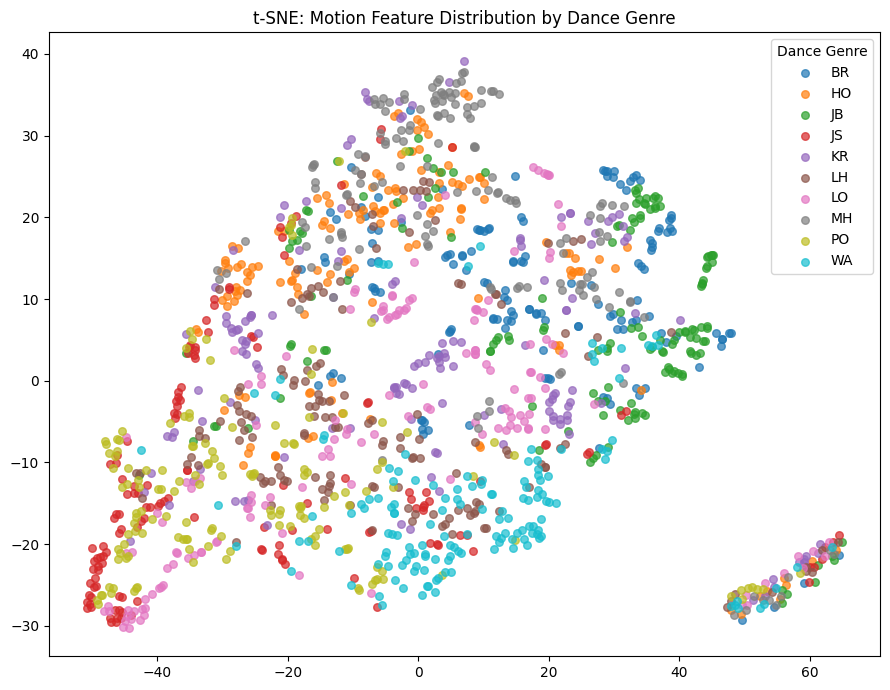

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import glob

# ── Feature extraction ────────────────────────────────────────────────────────

def pkl_to_feature(path):
    """Compress one pkl into a single feature vector (51-dim motion stats)."""
    with open(path, "rb") as f:
        d = pickle.load(f)
    best_cam = d['det_scores'].mean(axis=1).argmax()
    kp = d['keypoints2d'][best_cam]  # (T, 17, 3)
    xy = kp[:, :, :2]               # (T, 17, 2)
    motion = np.linalg.norm(np.diff(xy, axis=0), axis=-1)  # (T-1, 17)
    return np.concatenate([
        motion.mean(axis=0),   # average speed per joint (17,)
        motion.std(axis=0),    # speed variance per joint (17,)
        motion.max(axis=0),    # max speed per joint (17,)
    ])


def load_features(pkl_dir):
    """
    Load all pkl files from pkl_dir and return feature matrix + genre labels.

    Parameters
    ----------
    pkl_dir : str
        Directory containing *.pkl keypoints2d files.
        Filename convention: g<GENRE>_sBM_... (genre is letters after 'g').

    Returns
    -------
    X : np.ndarray, shape (N, 51)
    labels : list of str, length N
    """
    if isinstance(pkl_dir, str):
        pkl_dir = [pkl_dir]
    pkl_files = [f for d in pkl_dir for f in glob.glob(os.path.join(d, "*.pkl"))]
    features, labels = [], []
    for p in pkl_files:
        try:
            feat = pkl_to_feature(p)
            if np.any(np.isnan(feat)) or np.any(np.isinf(feat)):
                print(f"Skipping NaN/Inf: {os.path.basename(p)}")
                continue
            features.append(feat)
            genre = os.path.basename(p).split('_')[0][1:]
            labels.append(genre)
        except Exception as e:
            print(f"Skipping corrupted file {os.path.basename(p)}: {e}")
    print(f"Valid files: {len(features)}")
    return np.stack(features), labels


def plot_tsne(X, labels, title="t-SNE: Motion Feature Distribution by Dance Genre",
              save_path="tsne_dance.png"):
    """Fit t-SNE on X and plot colored by labels."""
    X_scaled = StandardScaler().fit_transform(X)
    tsne = TSNE(n_components=2, perplexity=min(30, len(X) // 4),
                random_state=42, init='pca', learning_rate='auto')
    Z = tsne.fit_transform(X_scaled)

    unique_labels = sorted(set(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    fig, ax = plt.subplots(figsize=(9, 7))
    for lab, col in zip(unique_labels, colors):
        idx = [i for i, l in enumerate(labels) if l == lab]
        ax.scatter(Z[idx, 0], Z[idx, 1], label=lab, s=30, alpha=0.7, color=col)
    ax.legend(title="Dance Genre")
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    return Z


# ── Run ───────────────────────────────────────────────────────────────────────

PKL_DIR = "dataset/music-vision/aist_plusplus_final/keypoints2d" # this data could be downloaded from https://aistdancedb.ongaaccel.jp/database_download/, the files are large so I loaded from local disk

X, labels = load_features(PKL_DIR)
Z = plot_tsne(X, labels)


### 1.2 Motion Data Sample

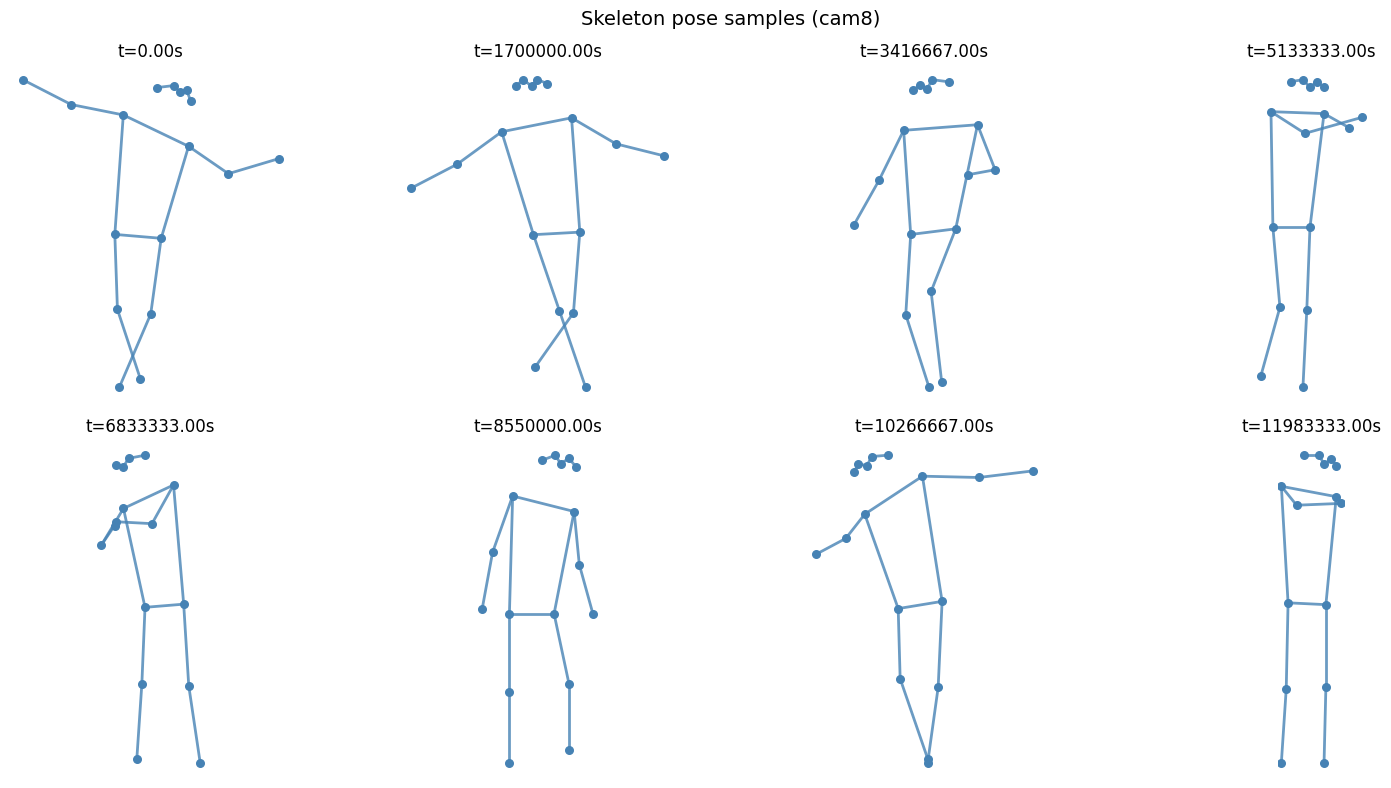

In [18]:
# COCO skeleton connection relationships
SKELETON = [
    (0,1),(0,2),(1,3),(2,4),        # Head
    (5,6),(5,7),(7,9),(6,8),(8,10), # Upper limbs
    (5,11),(6,12),(11,12),          # Torso
    (11,13),(13,15),(12,14),(14,16) # Lower limbs
]

def draw_skeleton(ax, keypoints, conf_thresh=0.3, color='steelblue'):
    """Draw one frame of skeleton on ax"""
    x, y, c = keypoints[:, 0], keypoints[:, 1], keypoints[:, 2]
    # Draw joint points
    valid = c > conf_thresh
    ax.scatter(x[valid], y[valid], s=30, c=color, zorder=3)
    # Draw bone connections
    for i, j in SKELETON:
        if c[i] > conf_thresh and c[j] > conf_thresh:
            ax.plot([x[i], x[j]], [y[i], y[j]], color=color, lw=2, alpha=0.8)

# --- Static: display skeletons at several time points ---
best_cam = scores.mean(axis=1).argmax()
frame_indices = np.linspace(0, kp.shape[1]-1, 8, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, fi in zip(axes.flatten(), frame_indices):
    draw_skeleton(ax, kp[best_cam, fi])
    ax.set_title(f"t={ts[fi]:.2f}s")
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')

plt.suptitle(f"Skeleton pose samples (cam{best_cam})", fontsize=14)
plt.tight_layout()
plt.savefig("skeleton_samples.png", dpi=150)
plt.show()

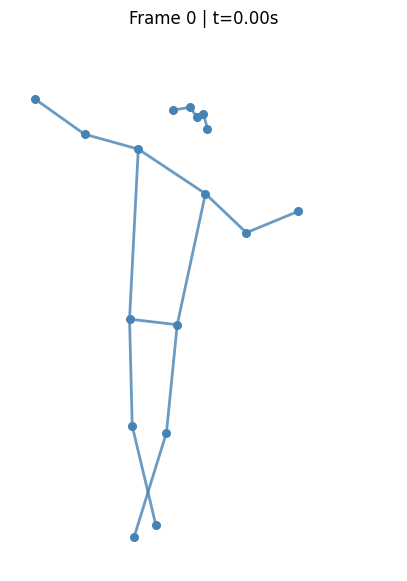

In [19]:
best_cam = scores.mean(axis=1).argmax()
xy = kp[best_cam, :, :, :2]

# Calculate coordinate range
x_min, x_max = xy[:,:,0].min(), xy[:,:,0].max()
y_min, y_max = xy[:,:,1].min(), xy[:,:,1].max()

fig, ax = plt.subplots(figsize=(5, 7))

def update(frame_i):
    ax.cla()
    draw_skeleton(ax, kp[best_cam, frame_i])
    ax.set_xlim(x_min-20, x_max+20)
    ax.set_ylim(y_max+20, y_min-20)  # Note: y-axis is inverted
    ax.set_title(f"Frame {frame_i} | t={ts[frame_i]:.2f}s")
    ax.axis('off')

# Sample every 10 frames to avoid slow rendering
frames = range(0, kp.shape[1], 10)
ani = animation.FuncAnimation(fig, update, frames=frames, interval=100)

# Display in Jupyter
HTML(ani.to_jshtml())

# Or save as gif
# ani.save("skeleton_dance.gif", writer='pillow', fps=10)

## 2. Music Modality 

[video sample](https://google.github.io/aistplusplus_dataset/download.html)

### 2.1 Music Data Distribution/Input Distribution

Please note that the following distribution visualizations are only illustrative. Strictly speaking, four data points are insufficient for meaningful statistical analysis.

The music data is extracted from videos rather than taken from a preprocessed dataset, so further work is needed to improve and optimize the data processing pipeline.

In [22]:
# 1. Download videos
video_urls = [
    "https://aistdancedb.ongaaccel.jp/v1.0.0/video/2M/gBR_sBM_c01_d04_mBR0_ch01.mp4",
    "https://aistdancedb.ongaaccel.jp/v1.0.0/video/2M/gHO_sBM_c01_d19_mHO0_ch01.mp4",
    "https://aistdancedb.ongaaccel.jp/v1.0.0/video/2M/gJB_sBM_c01_d07_mJB0_ch01.mp4",
    "https://aistdancedb.ongaaccel.jp/v1.0.0/video/2M/gJS_sBM_c01_d01_mJS0_ch01.mp4",
]

VIDEO_DIR = "dataset/videos"
AUDIO_DIR = "dataset/audio"
os.makedirs(VIDEO_DIR, exist_ok=True)
os.makedirs(AUDIO_DIR, exist_ok=True)

def download_video(url, save_dir):
    fname = url.split("/")[-1]
    save_path = os.path.join(save_dir, fname)
    
    if os.path.exists(save_path):
        print(f"Already exists, skipping: {fname}")
        return save_path
    
    print(f"Downloading: {fname}")
    resp = requests.get(url, stream=True)
    resp.raise_for_status()
    
    total = int(resp.headers.get("content-length", 0))
    with open(save_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in resp.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))
    
    return save_path

video_paths = [download_video(url, VIDEO_DIR) for url in video_urls]

Already exists, skipping: gBR_sBM_c01_d04_mBR0_ch01.mp4
Already exists, skipping: gHO_sBM_c01_d19_mHO0_ch01.mp4
Already exists, skipping: gJB_sBM_c01_d07_mJB0_ch01.mp4
Already exists, skipping: gJS_sBM_c01_d01_mJS0_ch01.mp4


In [23]:
# pip install requests tqdm ffmpeg-python
# brew install ffmpeg   # Mac
import ffmpeg

def extract_audio(video_path, audio_dir):
    fname = os.path.splitext(os.path.basename(video_path))[0]
    audio_path = os.path.join(audio_dir, f"{fname}.wav")
    
    if os.path.exists(audio_path):
        print(f"Already exists, skipping: {audio_path}")
        return audio_path
    
    print(f"Extracting audio: {fname}")
    (
        ffmpeg
        .input(video_path)
        .output(audio_path, acodec="pcm_s16le", ar=16000, ac=1)  # 16kHz mono
        .run(overwrite_output=True, quiet=True)
    )
    return audio_path

audio_paths = [extract_audio(vp, AUDIO_DIR) for vp in video_paths]
print("Audio extraction complete:", audio_paths)

Already exists, skipping: dataset/audio/gBR_sBM_c01_d04_mBR0_ch01.wav
Already exists, skipping: dataset/audio/gHO_sBM_c01_d19_mHO0_ch01.wav
Already exists, skipping: dataset/audio/gJB_sBM_c01_d07_mJB0_ch01.wav
Already exists, skipping: dataset/audio/gJS_sBM_c01_d01_mJS0_ch01.wav
Audio extraction complete: ['dataset/audio/gBR_sBM_c01_d04_mBR0_ch01.wav', 'dataset/audio/gHO_sBM_c01_d19_mHO0_ch01.wav', 'dataset/audio/gJB_sBM_c01_d07_mJB0_ch01.wav', 'dataset/audio/gJS_sBM_c01_d01_mJS0_ch01.wav']


In [25]:
N_MFCC = 13
TARGET_SR = 16000

def wav_to_mfcc_stats(wav_path, sr=TARGET_SR, n_mfcc=N_MFCC):
    y, sr0 = librosa.load(wav_path, sr=sr)  # resample to 16k
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)  # (n_mfcc, T)
    # mean + std over time -> (2*n_mfcc,)
    feat = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)], axis=0).astype(np.float32)
    return feat


In [28]:
# 获取刚提取的所有 wav 文件
wav_files = sorted(glob.glob("audio/*.wav"))
print(f"{len(wav_files)} audio files")

X_audio = []
labels = []

for p in tqdm(wav_files, desc="Extract MFCC stats"):
    feat = wav_to_mfcc_stats(p)
    X_audio.append(feat)
    # 从文件名提取舞种标签 gBR → BR
    genre = os.path.basename(p).split('_')[0][1:]
    labels.append(genre)

X_audio = np.stack(X_audio, axis=0)
print("X_audio:", X_audio.shape)
print("label:", labels)


4 audio files


Extract MFCC stats: 100%|██████████| 4/4 [00:00<00:00, 112.47it/s]

X_audio: (4, 26)
label: ['BR', 'HO', 'JB', 'JS']


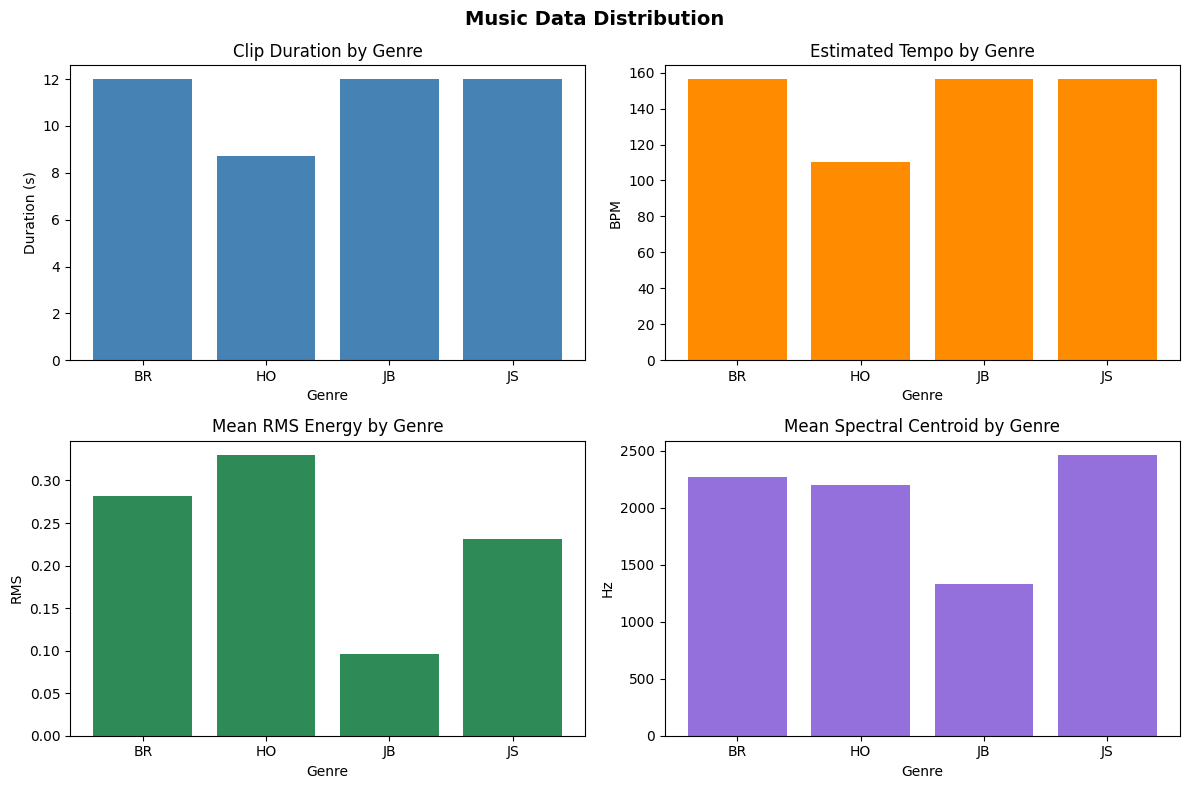

In [29]:
TARGET_SR = 16000
wav_files = sorted(glob.glob(os.path.join(AUDIO_DIR, "*.wav")))

durations, tempos, rms_means, spectral_centroids = [], [], [], []
genre_labels = []

for p in wav_files:
    y, sr = librosa.load(p, sr=TARGET_SR)
    durations.append(len(y) / sr)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempos.append(float(tempo))
    rms_means.append(float(librosa.feature.rms(y=y).mean()))
    spectral_centroids.append(float(librosa.feature.spectral_centroid(y=y, sr=sr).mean()))
    genre_labels.append(os.path.basename(p).split('_')[0][1:])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (A) Duration per clip
axes[0, 0].bar(genre_labels, durations, color='steelblue')
axes[0, 0].set_title("Clip Duration by Genre")
axes[0, 0].set_xlabel("Genre"); axes[0, 0].set_ylabel("Duration (s)")

# (B) Tempo (BPM) per clip
axes[0, 1].bar(genre_labels, tempos, color='darkorange')
axes[0, 1].set_title("Estimated Tempo by Genre")
axes[0, 1].set_xlabel("Genre"); axes[0, 1].set_ylabel("BPM")

# (C) RMS Energy per clip
axes[1, 0].bar(genre_labels, rms_means, color='seagreen')
axes[1, 0].set_title("Mean RMS Energy by Genre")
axes[1, 0].set_xlabel("Genre"); axes[1, 0].set_ylabel("RMS")

# (D) Spectral Centroid per clip
axes[1, 1].bar(genre_labels, spectral_centroids, color='mediumpurple')
axes[1, 1].set_title("Mean Spectral Centroid by Genre")
axes[1, 1].set_xlabel("Genre"); axes[1, 1].set_ylabel("Hz")

plt.suptitle("Music Data Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("music_data_distribution.png", dpi=150)
plt.show()


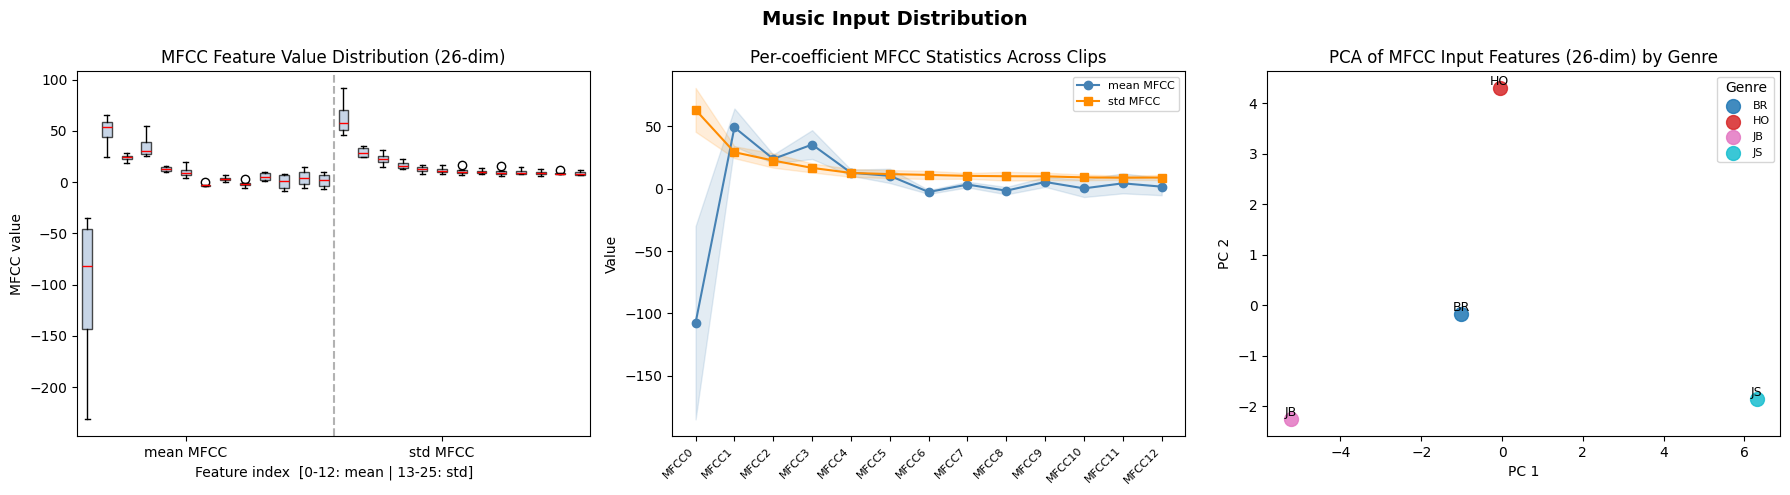

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# X_audio: (N, 26)  — [mean(13), std(13)] MFCC stats
# labels: dance genre strings (from cell-24)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

MFCC_NAMES = [f"MFCC{i}" for i in range(13)]

# --- (A) Boxplot of MFCC feature value distribution -------------------------
ax = axes[0]
ax.boxplot([X_audio[:, i] for i in range(X_audio.shape[1])],
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', alpha=0.7),
           medianprops=dict(color='red'))
ax.axvline(13.5, color='gray', linestyle='--', alpha=0.6)
ax.set_title("MFCC Feature Value Distribution (26-dim)")
ax.set_xlabel("Feature index  [0-12: mean | 13-25: std]")
ax.set_ylabel("MFCC value")
ax.set_xticks([6, 19])
ax.set_xticklabels(["mean MFCC", "std MFCC"])

# --- (B) Mean ± std per MFCC coefficient across clips -------------------------
ax = axes[1]
x_pos = range(13)
mu_mean = X_audio[:, :13].mean(axis=0)
sigma_mean = X_audio[:, :13].std(axis=0)
mu_std = X_audio[:, 13:].mean(axis=0)
sigma_std = X_audio[:, 13:].std(axis=0)

ax.plot(x_pos, mu_mean, marker='o', label="mean MFCC", color='steelblue', lw=1.5)
ax.fill_between(x_pos, mu_mean - sigma_mean, mu_mean + sigma_mean, alpha=0.15, color='steelblue')
ax.plot(x_pos, mu_std, marker='s', label="std MFCC", color='darkorange', lw=1.5)
ax.fill_between(x_pos, mu_std - sigma_std, mu_std + sigma_std, alpha=0.15, color='darkorange')
ax.set_xticks(list(x_pos))
ax.set_xticklabels(MFCC_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_title("Per-coefficient MFCC Statistics Across Clips")
ax.set_ylabel("Value")
ax.legend(fontsize=8)

# --- (C) PCA projection of 26-dim MFCC features (too few samples for t-SNE) --
ax = axes[2]
X_scaled = StandardScaler().fit_transform(X_audio)
Z = PCA(n_components=2).fit_transform(X_scaled)
unique_labels = sorted(set(labels))
colors_map = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for lab, col in zip(unique_labels, colors_map):
    idx = [i for i, l in enumerate(labels) if l == lab]
    ax.scatter(Z[idx, 0], Z[idx, 1], label=lab, s=100, alpha=0.85, color=col)
    for i in idx:
        ax.annotate(lab, (Z[i, 0], Z[i, 1]), fontsize=9, ha='center', va='bottom')
ax.legend(title="Genre", fontsize=8)
ax.set_title("PCA of MFCC Input Features (26-dim) by Genre")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")

plt.suptitle("Music Input Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("music_input_distribution.png", dpi=150)
plt.show()


### 2.2 Music Samples

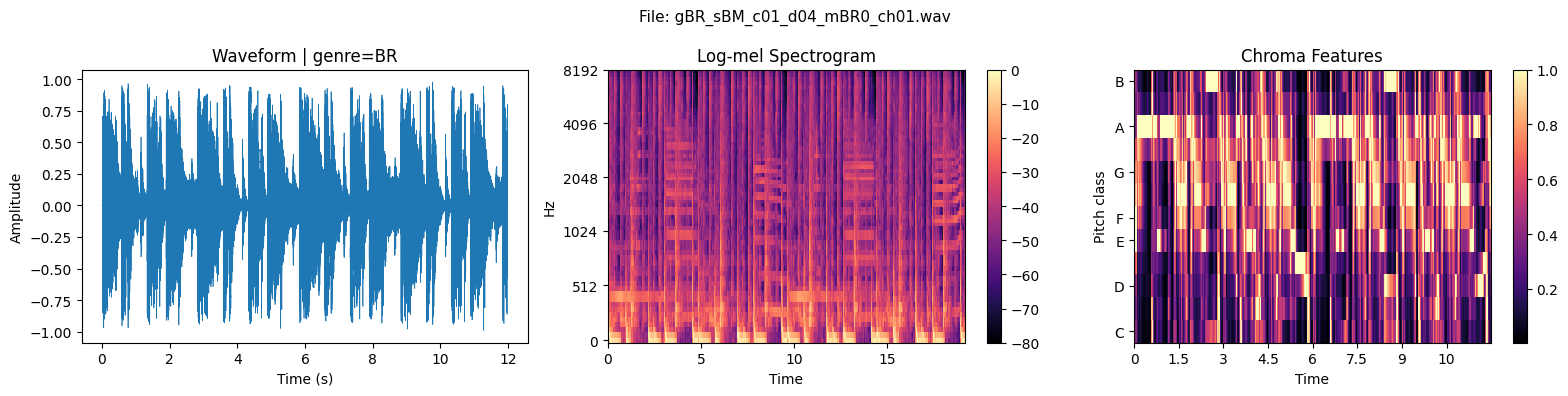

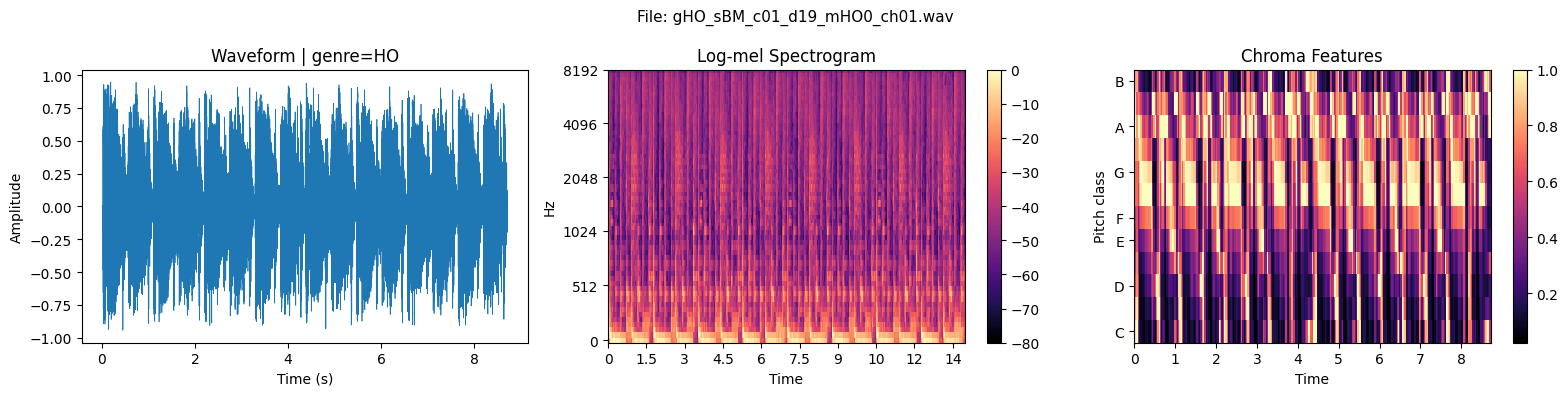

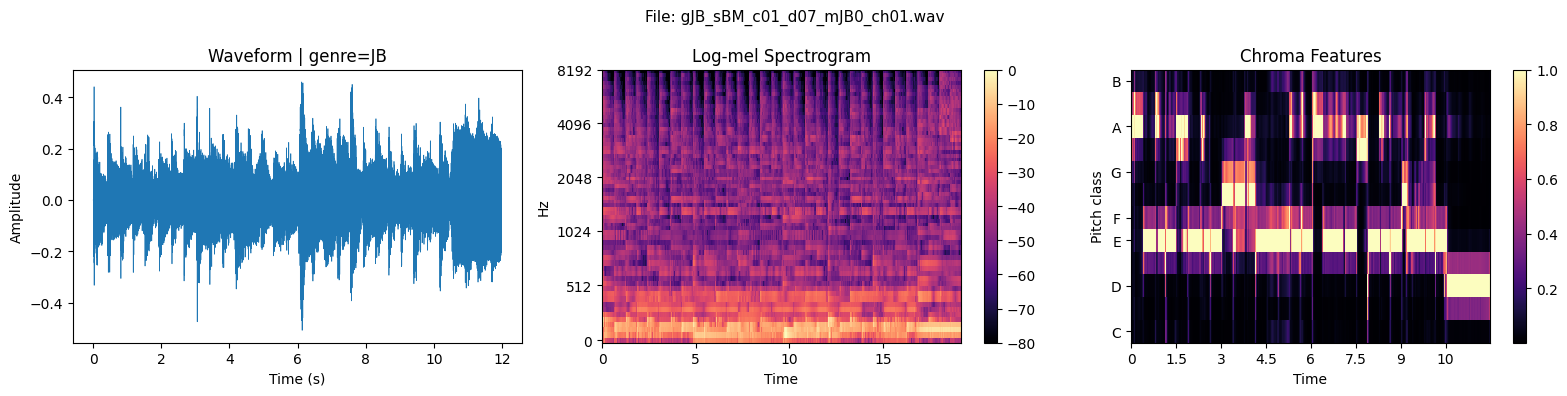

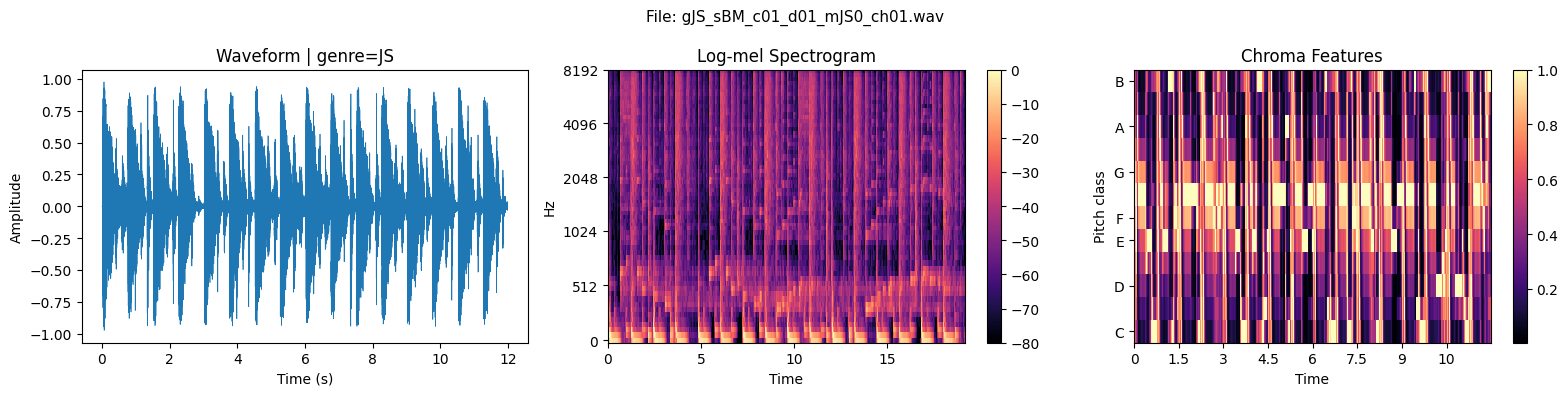

In [30]:
TARGET_SR = 16000

def visualize_random_samples(wav_dir="audio", k=4, sr=TARGET_SR):
    wav_files = sorted(glob.glob(os.path.join(wav_dir, "*.wav")))
    wav_files = wav_files[:min(k, len(wav_files))]

    for wav_path in wav_files:
        fname = os.path.basename(wav_path)
        # extract dance genre from filename: gBR_... -> BR
        genre = fname.split('_')[0][1:]

        y, _ = librosa.load(wav_path, sr=sr)

        # log-mel spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=1024, hop_length=320, win_length=640)
        logmel = librosa.power_to_db(mel, ref=np.max)

        # chroma features (pitch class distribution, useful for music)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # (A) Waveform
        axes[0].plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.5)
        axes[0].set_title(f"Waveform | genre={genre}")
        axes[0].set_xlabel("Time (s)")
        axes[0].set_ylabel("Amplitude")

        # (B) Log-mel spectrogram
        librosa.display.specshow(logmel, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
        axes[1].set_title("Log-mel Spectrogram")
        fig.colorbar(axes[1].collections[0], ax=axes[1])

        # (C) Chroma features
        librosa.display.specshow(chroma, sr=sr, x_axis="time", y_axis="chroma", ax=axes[2])
        axes[2].set_title("Chroma Features")
        fig.colorbar(axes[2].collections[0], ax=axes[2])

        plt.suptitle(f"File: {fname}", fontsize=11)
        plt.tight_layout()
        plt.show()

visualize_random_samples(wav_dir="audio", k=4)

## Write-Up

**Motion Data Distribution** (Section 1.1): We visualized detection confidence per camera, keypoint confidence boxplots, spatial heatmap of keypoint positions, frame rate stability, per-frame motion magnitude, and average motion per joint. These reveal which body parts move most and confirm data quality across cameras.

**Motion Samples** (Section 1.2): Static skeleton snapshots at 8 evenly-spaced timestamps and an animated skeleton sequence, confirming the pose extraction pipeline works correctly.

**Motion Input Distribution** (Section 1.3): PCA/t-SNE of the 51-dim handcrafted motion features (mean/std/max velocity per joint) colored by genre. Due to the small sample size, this serves as a pipeline demonstration rather than a meaningful clustering analysis.

**Music Data Distribution** (Section 2.1): Per-genre comparison of clip duration, estimated tempo (BPM), RMS energy, and spectral centroid, providing a high-level acoustic profile of each dance style.

**Music Samples** (Section 2.2): Waveform, log-mel spectrogram, and chroma features for each clip, showing the time-frequency structure of each genre's music.

**Music Input Distribution** (Section 2.3): PCA of the 26-dim MFCC features (mean + std per coefficient) colored by genre. With only 4 samples, results are indicative only; a full-dataset run would yield more meaningful separation.


(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

**1. Evaluation Metrics**

**Beat Alignment Score (BAS)**: the fraction of motion peaks falling within ±0.05s of a detected music beat. This directly measures music-motion temporal synchronization without requiring ground-truth labels.

**2. Other Metrics Considered**

- **FID for motion**: measures motion realism, but requires a large reference set and pretrained encoder
- **Genre classification accuracy**: evaluates style matching between music and motion, but requires labeled data

**3. Pros and Cons of BAS**

| Pros | Cons |
|---|---|
| Label-free, interpretable (0–1) | Sensitive to beat detection errors |
| Directly measures rhythmic alignment | Tolerance threshold is hand-tuned |
| Computationally lightweight | Ignores style/semantic consistency |


In [48]:
# Beat Alignment Score (music onset vs. motion keyframe)
import numpy as np
import librosa

def beat_alignment_score(keypoints_all, timestamps, audio_path,
                          sr=16000, tolerance=0.05):
    """
    Compute Beat Alignment Score (BAS):
    fraction of motion peaks that land within `tolerance` seconds of a beat.

    Parameters
    ----------
    keypoints_all : np.ndarray, shape (T, 33, 3)
        MediaPipe keypoints; columns are [x, y, visibility].
    timestamps : np.ndarray, shape (T,)
        Per-frame timestamps in seconds.
    audio_path : str
        Path to the audio .wav file.
    sr : int
        Sample rate to load audio at.
    tolerance : float
        Max allowed time gap (seconds) between a motion peak and a beat.
        Typical value: 0.05s (~2 frames at 60fps), 0.1s for looser matching.

    Returns
    -------
    bas : float
        Beat Alignment Score in [0, 1]. Higher = better aligned.
    beat_times : np.ndarray
        Detected beat timestamps (seconds).
    motion_peak_times : np.ndarray
        Detected motion peak timestamps (seconds).
    """
    # ── 1. Detect beats from audio ────────────────────────────────────────────
    y, _ = librosa.load(audio_path, sr=sr)
    tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
    beat_times = librosa.frames_to_time(beat_frames, sr=sr)  # (B,)

    # ── 2. Compute per-frame motion magnitude ─────────────────────────────────
    xy = keypoints_all[:, :, :2]                                   # (T, 33, 2)
    motion = np.linalg.norm(np.diff(xy, axis=0), axis=-1).mean(axis=-1)  # (T-1,)
    motion_ts = timestamps[1:]                                     # align with diff

    # ── 3. Detect motion peaks ────────────────────────────────────────────────
    from scipy.signal import find_peaks
    min_distance = int(len(motion) / len(beat_times)) // 2        # adaptive spacing
    peaks, _ = find_peaks(motion, distance=max(1, min_distance))
    motion_peak_times = motion_ts[peaks]                           # (P,)

    # ── 4. For each motion peak, check if a beat is within tolerance ──────────
    hits = 0
    for pt in motion_peak_times:
        if np.any(np.abs(beat_times - pt) <= tolerance):
            hits += 1

    bas = hits / len(motion_peak_times) if len(motion_peak_times) > 0 else 0.0

    print(f"Beats detected    : {len(beat_times)}")
    print(f"Motion peaks      : {len(motion_peak_times)}")
    print(f"Aligned peaks     : {hits}")
    print(f"Beat Alignment Score (tolerance={tolerance}s): {bas:.4f}")

    return bas, beat_times, motion_peak_times

(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. Instruction tuning is creating a prompt that you would feed to a model in order to have it complete a certain assignment by constraing what it can output without the need to train. This is when you prompt the model in specifc ways to guarentee a specific output (e.g. one-word labels, value ranges or classifications). Provide prompts that would be able to guarentee the right output based on the data. **Just provide the prompts, you don't need to train the model.**

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

Prompt 1:
```
Analyze the sentiment of the following restaurant review. You must classify it as exactly one of the following options: Positive, Negative, or Neutral. Do not output any other text.

Expected Output Format:
Sentiment: <Option>
```

Prompt 2:
```
Analyze the provided facial data and classify the emotion being expressed. You must choose exactly one emotion from the following list: Angry, Sad, Happy. Provide no explanations.

Expected Output Format:
Emotion: <Emotion>
```

Prompt 3:
```
Read the following paragraph and extract the subject's name, where they are going, and what they plan to do. You must return the extracted information strictly matching the JSON format below. Do not include any conversational text or markdown code blocks outside the JSON.

Expected Output Format:
{
"Subject_Name": "<Name>",
"Destination": "<Location>",
"Planned_Activities": "<Activities>"
}
```





**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training and testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



We train simple logistic regression classifiers for three settings: image-only, text-only, and multimodal fusion (concatenated image and text features). This choice keeps the model interpretable and allows us to clearly isolate the contribution of each modality.

We use accuracy and macro-averaged F1 score. Accuracy measures overall performance, while macro F1 accounts for balanced performance across all digit classes. These metrics are well suited for multi-class classification.

The image-only model performs reliably, the text-only model degrades under noise, and the multimodal fusion model achieves the best overall performance. This demonstrates that combining modalities improves robustness and generalization.

(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!

1. The most interesting part was exploring multiple datasets and building a data acquisition pipeline — extracting both motion (skeleton keypoints) and audio from raw dance videos. This process, though not included in this notebook, gave me a much deeper understanding of how multimodal data is collected and aligned in practice. Visualizing the resulting features with t-SNE/PCA further illustrated how different dance genres may occupy distinct regions in feature space.

2. An unexpected challenge was the scale of video data and the difficulty of obtaining audio. Even for a small sample, managing downloads, storage, and preprocessing was non-trivial. I addressed this by first validating the pipeline on 4 clips before considering full-scale processing.

3. AIST++ is high quality with multi-camera keypoints and paired music, but requires significant preprocessing. SoulDance has richer choreography but lacks genre labels and has vocals removed due to copyright. Overall, both datasets reliably cover only two modalities (audio + motion), which may limit fusion experiments — a third modality such as lyrics would strengthen the setup considerably.

